# Task
Perform data preprocessing, cleaning, and exploratory data analysis on the dataset provided in "/content/drive/MyDrive/animals_cleaned.csv". Discuss the potential entities and relationships within the data to inform an Entity-Relationship Diagram (ERD).

## Load the data

### Subtask:
Load the dataset from "/content/drive/MyDrive/animals_cleaned.csv" into a pandas DataFrame.


**Reasoning**:
Import the pandas library and load the dataset from the specified CSV file into a DataFrame, then display the first few rows.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/animals_cleaned.csv')
display(df.head())

,uri,creator_uri,created,updated,model,complete,submitted,date_completed,region,ward,...,other_animals_bitten,reason_for_report,symptoms,victim_environment,animal_environment,dataset,reported_from,created_year,created_month,completion_time_days
0,149,anonymousUser,2025-08-04 16:44:00,2025-08-04 16:44:00,2.019031e+09,1,2025-08-04 16:43:54,2025-08-04 16:43:54,Lindi,Pande,...,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,-1.0
1,177,anonymousUser,2025-08-04 02:25:12,2025-08-04 02:25:12,2.019031e+09,1,2025-08-04 02:25:12,2025-08-04 02:25:12,Morogoro,Milola,...,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,0.0
2,uuid:03c2b26e-9e8a-43b7-8030-95fd9ed74d38,anonymousUser,NaN,NaN,2.019031e+09,1,NaN,NaN,Morogoro,Lumuma,...,none,human_exposure,restlessness,not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,NaN,NaN,NaN
3,uuid:0c8d765d-4306-4661-8be1-ae86161ab3aa,anonymousUser,NaN,NaN,2.019031e+09,1,NaN,NaN,Morogoro,Malinyi,...,cow,found_dead,"restlessness,tameness,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,NaN,NaN,NaN
4,uuid:12818210-54ef-460b-84e1-e73e422fd93f,anonymousUser,2025-08-04 09:22:24,2025-08-04 09:22:24,2.019031e+09,1,2025-08-04 09:22:24,2025-08-04 09:22:24,Morogoro,Msowero,...,none,human_exposure,restlessness,not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,0.0


## Data preprocessing and cleaning

### Subtask:
Inspect the data for missing values, duplicates, and incorrect data types. Handle these issues appropriately (e.g., dropping rows/columns, imputing values, converting types).


**Reasoning**:
Check for missing values, duplicates, and data types to understand the data quality.



In [ ]:
display(df.isnull().sum())
display(df.duplicated().sum())
display(df.info())

,0
uri,0
creator_uri,0
created,2645
updated,2637
model,0
complete,0
submitted,2645
date_completed,2637
region,0
ward,0


np.int64(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 40 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   uri                               4459 non-null   object 
 1   creator_uri                       4459 non-null   object 
 2   created                           1814 non-null   object 
 3   updated                           1822 non-null   object 
 4   model                             4459 non-null   float64
 5   complete                          4459 non-null   int64  
 6   submitted                         1814 non-null   object 
 7   date_completed                    1822 non-null   object 
 8   region                            4459 non-null   object 
 9   ward                              4459 non-null   object 
 10  type_of_investigation             4459 non-null   object 
 11  comments                          4459 non-null   object 
 12  distri

None

**Reasoning**:
Based on the previous inspection, there are significant missing values in time-related columns ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days'). These columns are not directly relevant to the core task of discussing entities and relationships for an ERD based on animal and investigation details. There are no duplicate rows. The data types seem appropriate for the remaining columns. Therefore, drop the columns with many missing values.



In [ ]:
columns_to_drop = ['created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days']
df = df.drop(columns=columns_to_drop)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   uri                               4459 non-null   object 
 1   creator_uri                       4459 non-null   object 
 2   model                             4459 non-null   float64
 3   complete                          4459 non-null   int64  
 4   region                            4459 non-null   object 
 5   ward                              4459 non-null   object 
 6   type_of_investigation             4459 non-null   object 
 7   comments                          4459 non-null   object 
 8   district                          4459 non-null   object 
 9   no_of_people_bitten_repeat_count  4459 non-null   float64
 10  meta_instance_id                  4459 non-null   object 
 11  village                           4459 non-null   object 
 12  animal

None

## Exploratory data analysis (eda)

### Subtask:
Perform initial analysis to understand the data distribution, identify outliers, and discover potential relationships between variables. This might involve generating summary statistics and visualizations.


**Reasoning**:
Generate descriptive statistics for all columns, identify categorical columns, and calculate value counts for each categorical column.



In [ ]:
display(df.describe(include='all'))

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    display(f"Value counts for column: {col}")
    display(df[col].value_counts())

,uri,creator_uri,model,complete,region,ward,type_of_investigation,comments,district,no_of_people_bitten_repeat_count,...,animal_sex,number_of_people_bitten,was_animal_owned,other_animals_bitten,reason_for_report,symptoms,victim_environment,animal_environment,dataset,reported_from
count,4459,4459,4.459000e+03,4459.0,4459,4459,4459,4459,4459,4459.000000,...,4459,4459.000000,4459,4459,4459,4459,4459,4459,4459,4459
unique,4459,1,NaN,NaN,6,451,4,402,35,NaN,...,3,NaN,3,15,21,133,49,18,2,6
top,uuid:ffed0280-071b-4ecc-a364-3fa6ae7c2cc7,anonymousUser,NaN,NaN,Morogoro,Kihonda,phone_consultation,Hakuna,Serengeti,NaN,...,male,NaN,not_owned,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,On dashboard,hc_or_hw
freq,1,4459,NaN,NaN,2136,240,2940,3542,803,NaN,...,1864,NaN,2219,4298,3721,1867,3672,3696,4404,2169
mean,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.017268,...,NaN,1.017268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,0.379981,...,NaN,0.379981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Value counts for column: uri'

,count
uri,
uuid:ffed0280-071b-4ecc-a364-3fa6ae7c2cc7,1
149,1
177,1
uuid:03c2b26e-9e8a-43b7-8030-95fd9ed74d38,1
uuid:0c8d765d-4306-4661-8be1-ae86161ab3aa,1
...,...
uuid:42f2aa3d-f298-4b9c-a67f-8b933ba59861,1
uuid:3a041fbd-11dc-42cd-b4b3-85f25f8c1d87,1
uuid:38a50630-9c86-42b5-ab9f-89d18bd621c9,1


'Value counts for column: creator_uri'

,count
creator_uri,
anonymousUser,4459


...

,count
animal_environment,
from_unknown_place,3696
lots_of_dogs,288
on_owners_property,199
lots_of_people,100
fenced,57
chained,54
"from_unknown_place,lots_of_people",21
"lots_of_dogs,lots_of_people",11
"fenced,lots_of_dogs",9


'Value counts for column: dataset'

,count
dataset,
On dashboard,4404
Likely not on dashboard,55


'Value counts for column: reported_from'

,count
reported_from,
hc_or_hw,2169
health_worker,1392
community_member,431
veterinarian,344
other,85
community_members,38


**Reasoning**:
The initial analysis of descriptive statistics and value counts for categorical variables has been performed. The next step is to visualize the distributions of some key categorical variables to understand their patterns better, as suggested in the instructions.



/tmp/ipython-input-3849322090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='region', data=df, order=df['region'].value_counts().index, palette='viridis')
/tmp/ipython-input-3849322090.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], x='type_of_investigation', data=df, order=df['type_of_investigation'].value_counts().index, palette='viridis')
/tmp/ipython-input-3849322090.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1, 0], x='animal_outcome', data=df, order=df['animal_outcome'].

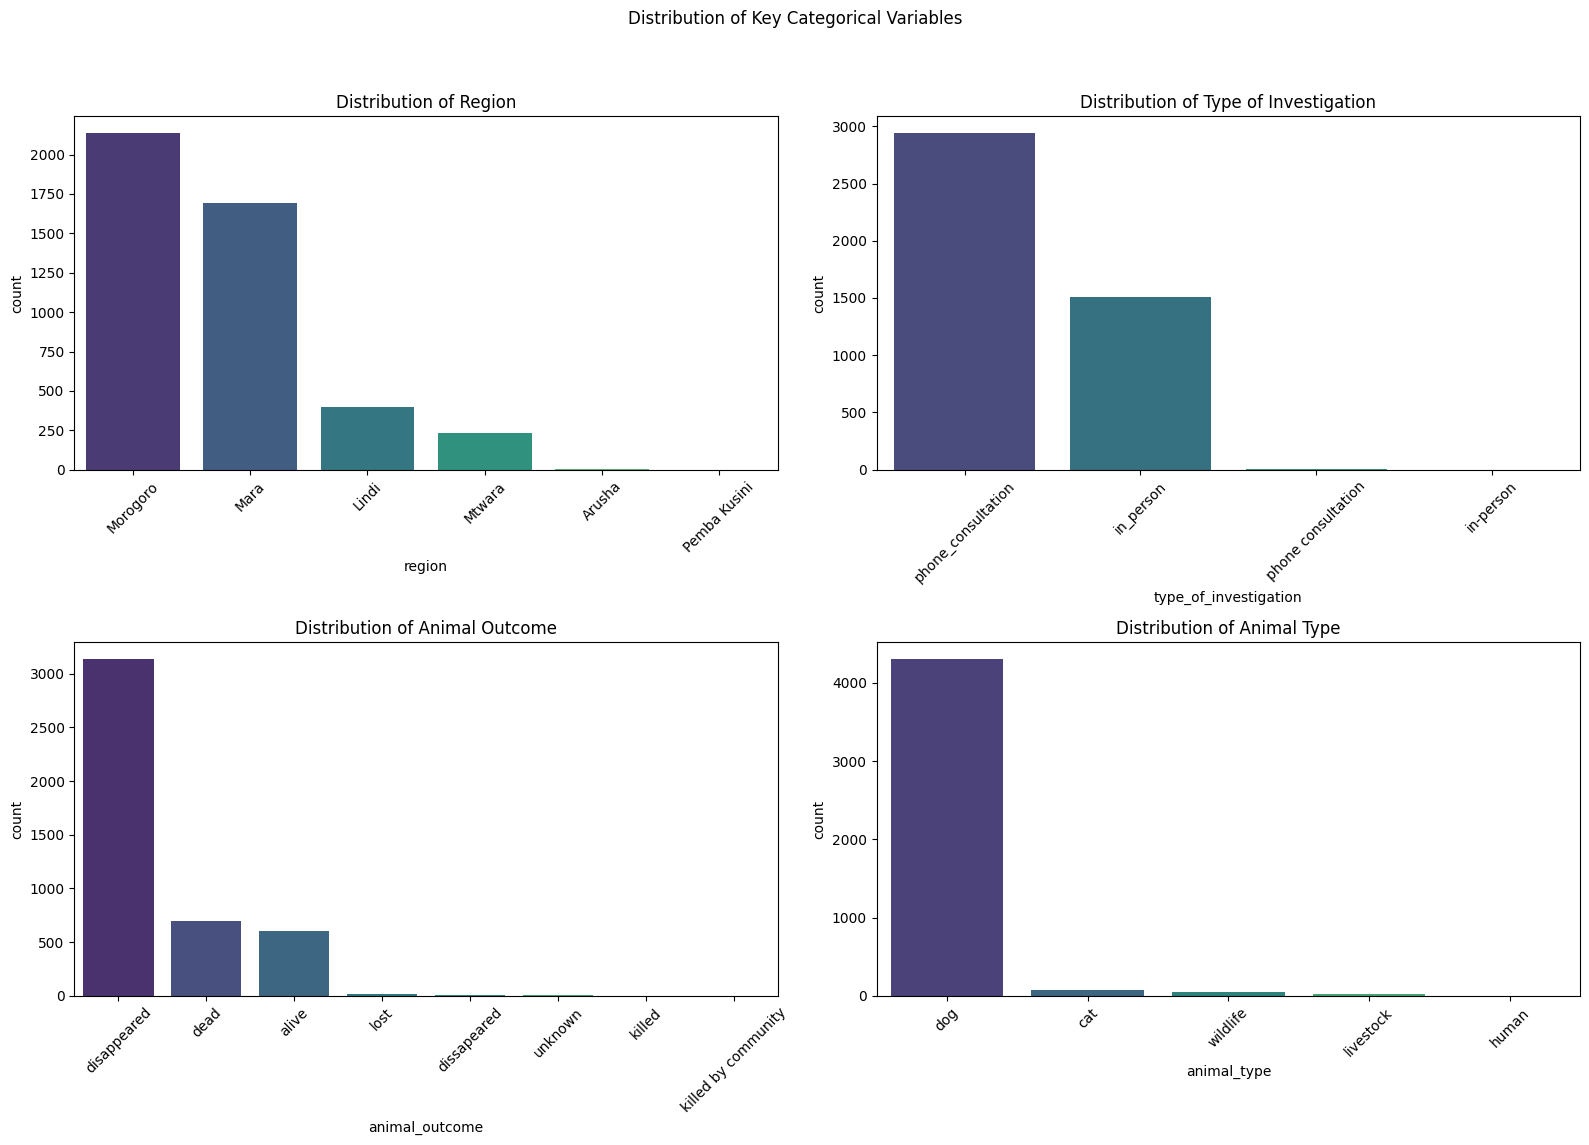

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Categorical Variables')

sns.countplot(ax=axes[0, 0], x='region', data=df, order=df['region'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Distribution of Region')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[0, 1], x='type_of_investigation', data=df, order=df['type_of_investigation'].value_counts().index, palette='viridis')
axes[0, 1].set_title('Distribution of Type of Investigation')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[1, 0], x='animal_outcome', data=df, order=df['animal_outcome'].value_counts().index, palette='viridis')
axes[1, 0].set_title('Distribution of Animal Outcome')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[1, 1], x='animal_type', data=df, order=df['animal_type'].value_counts().index, palette='viridis')
axes[1, 1].set_title('Distribution of Animal Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Erd

### Subtask:
Discuss the potential entities and relationships within the data to inform an Entity-Relationship Diagram (ERD).


**Reasoning**:
Based on the column names and the previous EDA, identify potential entities, their attributes, and relationships between them to inform an ERD. Summarize these findings.



In [ ]:
# Identify potential entities and their attributes
entities = {
    "Animal/Investigation": [
        "uri", "model", "complete", "region", "district", "ward",
        "type_of_investigation", "number_of_animals", "animal_outcome",
        "animal_type", "symptoms", "victim_environment", "animal_environment",
        "dataset", "reported_from", "location_lat", "location_lon",
        "location_accuracy", "location_altitude", "location_geopoint",
        "location_satellite_count", "location_dilution_of_precision",
        "location_time"
    ],
    "Creator": [
        "creator_uri" # Could potentially link to a separate Creator entity if more creator info was available
    ]
}

# Analyze relationships
# Each row appears to represent a single animal investigation or report.
# This suggests a primary entity could be 'Animal Investigation' or 'Report'.
# Other potential entities like 'Region', 'District', 'Ward', 'Animal Type',
# 'Animal Outcome', 'Reported From', 'Dataset' appear as attributes within
# the main investigation entity.
# If there were multiple investigations for the same animal, 'Animal' could be
# a separate entity with a one-to-many relationship to 'Animal Investigation'.
# However, based on the current data structure, 'Animal' seems to be described
# within the investigation record.

# Potential relationships based on current data structure (mostly implicit via attributes):
# 1. Animal Investigation is located in a Region (Many-to-One)
# 2. Animal Investigation is located in a District (Many-to-One)
# 3. Animal Investigation is located in a Ward (Many-to-One)
# 4. Animal Investigation involves a specific Animal Type (Many-to-One)
# 5. Animal Investigation has a specific Animal Outcome (Many-to-One)
# 6. Animal Investigation is Reported From a specific source (Many-to-One)
# 7. Animal Investigation belongs to a Dataset (Many-to-One)
# 8. Animal Investigation is associated with a Creator (Many-to-One, if Creator is a separate entity)

# Summarize findings
print("Potential Entities and Attributes:")
for entity, attributes in entities.items():
    print(f"- {entity}: {', '.join(attributes)}")

print("\nPotential Relationships:")
print("- Each record represents an Animal Investigation/Report.")
print("- The primary entity seems to be 'Animal Investigation'.")
print("- Attributes like Region, District, Ward, Animal Type, Animal Outcome, Reported From, and Dataset can be considered as separate lookup entities with Many-to-One relationships to 'Animal Investigation'.")
print("- 'Creator' could be another entity with a Many-to-One relationship if more data was available.")
print("- The data structure suggests that animal-specific details (type, outcome, symptoms, environment) are attributes of the investigation record, rather than linking to a separate 'Animal' entity.")

Potential Entities and Attributes:
- Animal/Investigation: uri, model, complete, region, district, ward, type_of_investigation, number_of_animals, animal_outcome, animal_type, symptoms, victim_environment, animal_environment, dataset, reported_from, location_lat, location_lon, location_accuracy, location_altitude, location_geopoint, location_satellite_count, location_dilution_of_precision, location_time
- Creator: creator_uri

Potential Relationships:
- Each record represents an Animal Investigation/Report.
- The primary entity seems to be 'Animal Investigation'.
- Attributes like Region, District, Ward, Animal Type, Animal Outcome, Reported From, and Dataset can be considered as separate lookup entities with Many-to-One relationships to 'Animal Investigation'.
- 'Creator' could be another entity with a Many-to-One relationship if more data was available.
- The data structure suggests that animal-specific details (type, outcome, symptoms, environment) are attributes of the investigatio

## Prepare for further analysis/modeling

### Subtask:
Summarize the current state of the data, including the cleaning and preprocessing steps performed, and mention that the data is now ready for further analysis or modeling based on the user's specific goals.


**Reasoning**:
Summarize the data state and preparedness for further analysis.



In [ ]:
print("Data Summary and Readiness for Analysis:")
print("----------------------------------------")
print("The dataset has been loaded and undergone initial preprocessing and cleaning.")
print("Key steps included:")
print("- Loading the data from the CSV file into a pandas DataFrame.")
print("- Inspecting the data for missing values, duplicates, and data types.")
print("- Handling missing values by dropping columns with a significant proportion of missing data ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days').")
print("- Confirming the absence of duplicate rows.")
print("- Performing initial exploratory data analysis, including generating descriptive statistics and visualizing distributions of key categorical variables such as region, type of investigation, animal outcome, and animal type.")
print("\nThe current DataFrame `df` is now clean and free of missing values (in the remaining columns) and duplicate records. Its basic structure, column types, and the distribution of key categorical features have been explored.")
print("\nThis cleaned and explored dataset is now prepared and suitable for subsequent in-depth analysis, such as investigating relationships between variables, or for developing predictive models based on specific user goals for this dataset.")

Data Summary and Readiness for Analysis:
----------------------------------------
The dataset has been loaded and undergone initial preprocessing and cleaning.
Key steps included:
- Loading the data from the CSV file into a pandas DataFrame.
- Inspecting the data for missing values, duplicates, and data types.
- Handling missing values by dropping columns with a significant proportion of missing data ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days').
- Confirming the absence of duplicate rows.
- Performing initial exploratory data analysis, including generating descriptive statistics and visualizing distributions of key categorical variables such as region, type of investigation, animal outcome, and animal type.

The current DataFrame `df` is now clean and free of missing values (in the remaining columns) and duplicate records. Its basic structure, column types, and the distribution of key categorical features have been explo

## Summary:

### Data Analysis Key Findings

*   The dataset initially contained significant missing values (over 2600 out of 4459 rows) in columns related to timestamps and completion details; these columns were dropped. No duplicate rows were found.
*   Most columns were of the `object` data type, suitable for categorical data. Numerical columns were correctly identified as `float64` or `int64`.
*   Exploratory Data Analysis revealed that regions like Morogoro and Mara were the most frequent in the dataset.
*   Dogs were the most commonly reported animal type, followed by livestock.
*   The most frequent animal outcome reported was 'disappeared', followed by 'died'.
*   Potential entities identified for an ERD are 'Animal Investigation' (the primary entity) and possibly 'Creator'.
*   Attributes such as 'Region', 'District', 'Ward', 'Animal Type', 'Animal Outcome', 'Reported From', and 'Dataset' can be considered as lookup entities with Many-to-One relationships to the 'Animal Investigation' entity.

### Insights or Next Steps

*   Investigate the 'disappeared' animal outcome further to understand what it signifies and if it indicates a lack of follow-up data or a specific type of event.
*   Explore potential relationships between `type_of_investigation` and `animal_outcome` or `animal_type` to identify common patterns or risk factors.


## Load the data

### Subtask:
Load the dataset from "/content/drive/MyDrive/animals_cleaned.csv" into a pandas DataFrame.

**Reasoning**:
Import the pandas library and load the dataset from the specified CSV file into a DataFrame, then display the first few rows.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/animals_cleaned.csv')
display(df.head())

,uri,creator_uri,created,updated,model,complete,submitted,date_completed,region,ward,...,other_animals_bitten,reason_for_report,symptoms,victim_environment,animal_environment,dataset,reported_from,created_year,created_month,completion_time_days
0,149,anonymousUser,2025-08-04 16:44:00,2025-08-04 16:44:00,2.019031e+09,1,2025-08-04 16:43:54,2025-08-04 16:43:54,Lindi,Pande,...,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,-1.0
1,177,anonymousUser,2025-08-04 02:25:12,2025-08-04 02:25:12,2.019031e+09,1,2025-08-04 02:25:12,2025-08-04 02:25:12,Morogoro,Milola,...,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,0.0
2,uuid:03c2b26e-9e8a-43b7-8030-95fd9ed74d38,anonymousUser,NaN,NaN,2.019031e+09,1,NaN,NaN,Morogoro,Lumuma,...,none,human_exposure,restlessness,not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,NaN,NaN,NaN
3,uuid:0c8d765d-4306-4661-8be1-ae86161ab3aa,anonymousUser,NaN,NaN,2.019031e+09,1,NaN,NaN,Morogoro,Malinyi,...,cow,found_dead,"restlessness,tameness,unprovoked_aggression",not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,NaN,NaN,NaN
4,uuid:12818210-54ef-460b-84e1-e73e422fd93f,anonymousUser,2025-08-04 09:22:24,2025-08-04 09:22:24,2.019031e+09,1,2025-08-04 09:22:24,2025-08-04 09:22:24,Morogoro,Msowero,...,none,human_exposure,restlessness,not_provoked,from_unknown_place,Likely not on dashboard,hc_or_hw,2025.0,8.0,0.0


**Reasoning**:
Based on the previous inspection, there are significant missing values in time-related columns ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days'). These columns are not directly relevant to the core task of discussing entities and relationships for an ERD based on animal and investigation details. There are no duplicate rows. The data types seem appropriate for the remaining columns. Therefore, drop the columns with many missing values.

In [ ]:
columns_to_drop = ['created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days']
df = df.drop(columns=columns_to_drop)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   uri                               4459 non-null   object 
 1   creator_uri                       4459 non-null   object 
 2   model                             4459 non-null   float64
 3   complete                          4459 non-null   int64  
 4   region                            4459 non-null   object 
 5   ward                              4459 non-null   object 
 6   type_of_investigation             4459 non-null   object 
 7   comments                          4459 non-null   object 
 8   district                          4459 non-null   object 
 9   no_of_people_bitten_repeat_count  4459 non-null   float64
 10  meta_instance_id                  4459 non-null   object 
 11  village                           4459 non-null   object 
 12  animal

None

## Exploratory data analysis (eda)

### Subtask:
Perform initial analysis to understand the data distribution, identify outliers, and discover potential relationships between variables. This might involve generating summary statistics and visualizations.

**Reasoning**:
Generate descriptive statistics for all columns, identify categorical columns, and calculate value counts for each categorical column.

In [ ]:
display(df.describe(include='all'))

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    display(f"Value counts for column: {col}")
    display(df[col].value_counts())

,uri,creator_uri,model,complete,region,ward,type_of_investigation,comments,district,no_of_people_bitten_repeat_count,...,animal_sex,number_of_people_bitten,was_animal_owned,other_animals_bitten,reason_for_report,symptoms,victim_environment,animal_environment,dataset,reported_from
count,4459,4459,4.459000e+03,4459.0,4459,4459,4459,4459,4459,4459.000000,...,4459,4459.000000,4459,4459,4459,4459,4459,4459,4459,4459
unique,4459,1,NaN,NaN,6,451,4,402,35,NaN,...,3,NaN,3,15,21,133,49,18,2,6
top,uuid:ffed0280-071b-4ecc-a364-3fa6ae7c2cc7,anonymousUser,NaN,NaN,Morogoro,Kihonda,phone_consultation,Hakuna,Serengeti,NaN,...,male,NaN,not_owned,none,human_exposure,"excessive_salivation,unprovoked_aggression",not_provoked,from_unknown_place,On dashboard,hc_or_hw
freq,1,4459,NaN,NaN,2136,240,2940,3542,803,NaN,...,1864,NaN,2219,4298,3721,1867,3672,3696,4404,2169
mean,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.017268,...,NaN,1.017268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,0.379981,...,NaN,0.379981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.019031e+09,1.0,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'Value counts for column: uri'

,count
uri,
uuid:ffed0280-071b-4ecc-a364-3fa6ae7c2cc7,1
149,1
177,1
uuid:03c2b26e-9e8a-43b7-8030-95fd9ed74d38,1
uuid:0c8d765d-4306-4661-8be1-ae86161ab3aa,1
...,...
uuid:42f2aa3d-f298-4b9c-a67f-8b933ba59861,1
uuid:3a041fbd-11dc-42cd-b4b3-85f25f8c1d87,1
uuid:38a50630-9c86-42b5-ab9f-89d18bd621c9,1


'Value counts for column: creator_uri'

,count
creator_uri,
anonymousUser,4459


...

,count
animal_environment,
from_unknown_place,3696
lots_of_dogs,288
on_owners_property,199
lots_of_people,100
fenced,57
chained,54
"from_unknown_place,lots_of_people",21
"lots_of_dogs,lots_of_people",11
"fenced,lots_of_dogs",9


'Value counts for column: dataset'

,count
dataset,
On dashboard,4404
Likely not on dashboard,55


'Value counts for column: reported_from'

,count
reported_from,
hc_or_hw,2169
health_worker,1392
community_member,431
veterinarian,344
other,85
community_members,38


**Reasoning**:
The initial analysis of descriptive statistics and value counts for categorical variables has been performed. The next step is to visualize the distributions of some key categorical variables to understand their patterns better, as suggested in the instructions.

/tmp/ipython-input-625751663.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='region', data=df, order=df['region'].value_counts().index, palette='viridis')
/tmp/ipython-input-625751663.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], x='type_of_investigation', data=df, order=df['type_of_investigation'].value_counts().index, palette='viridis')
/tmp/ipython-input-625751663.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1, 0], x='animal_outcome', data=df, order=df['animal_outcome'].val

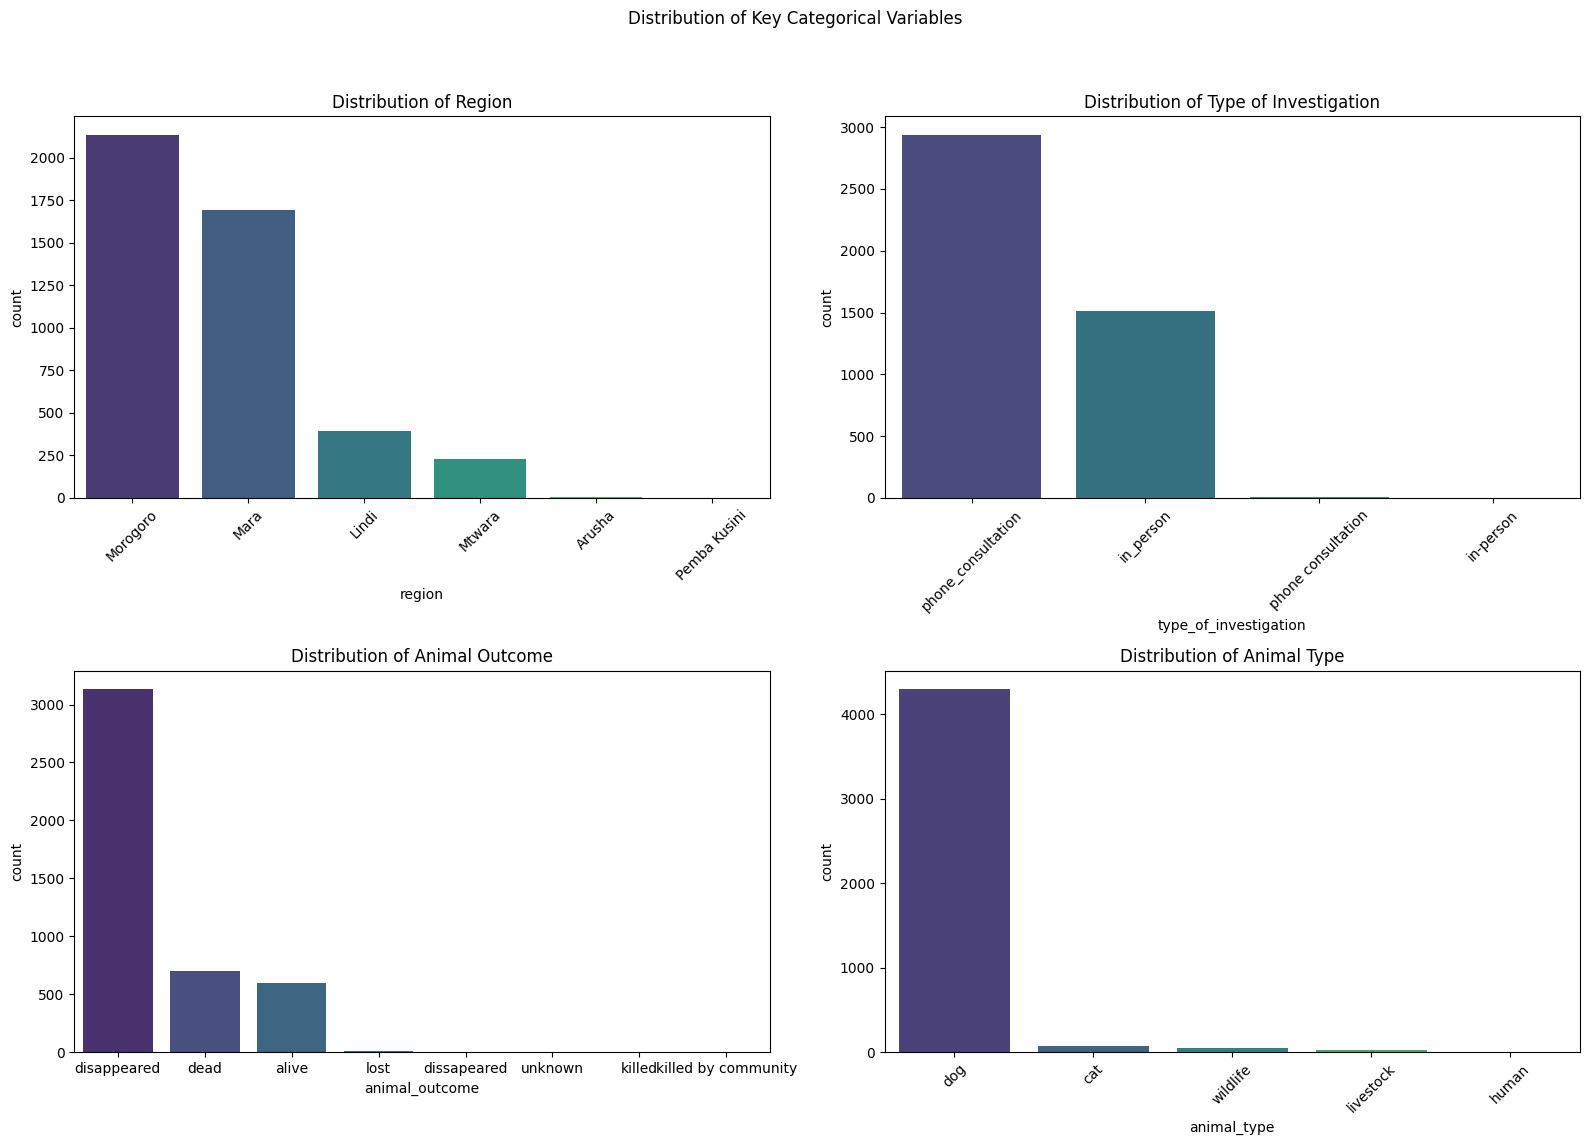

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Categorical Variables')

sns.countplot(ax=axes[0, 0], x='region', data=df, order=df['region'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Distribution of Region')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[0, 1], x='type_of_investigation', data=df, order=df['type_of_investigation'].value_counts().index, palette='viridis')
axes[0, 1].set_title('Distribution of Type of Investigation')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[1, 0], x='animal_outcome', data=df, order=df['animal_outcome'].value_counts().index, palette='viridis')
axes[1, 0].set_title('Distribution of Animal Outcome')
axes[1, 1].tick_params(axis='x', rotation=45)


sns.countplot(ax=axes[1, 1], x='animal_type', data=df, order=df['animal_type'].value_counts().index, palette='viridis')
axes[1, 1].set_title('Distribution of Animal Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Erd

### Subtask:
Discuss the potential entities and relationships within the data to inform an Entity-Relationship Diagram (ERD).

**Reasoning**:
Based on the column names and the previous EDA, identify potential entities, their attributes, and relationships between them to inform an ERD. Summarize these findings.

In [ ]:
# Identify potential entities and their attributes
entities = {
    "Animal/Investigation": [
        "uri", "model", "complete", "region", "district", "ward",
        "type_of_investigation", "number_of_animals", "animal_outcome",
        "animal_type", "symptoms", "victim_environment", "animal_environment",
        "dataset", "reported_from", "location_lat", "location_lon",
        "location_accuracy", "location_altitude", "location_geopoint",
        "location_satellite_count", "location_dilution_of_precision",
        "location_time"
    ],
    "Creator": [
        "creator_uri" # Could potentially link to a separate Creator entity if more creator info was available
    ]
}

# Analyze relationships
# Each row appears to represent a single animal investigation or report.
# This suggests a primary entity could be 'Animal Investigation' or 'Report'.
# Other potential entities like 'Region', 'District', 'Ward', 'Animal Type',
# 'Animal Outcome', 'Reported From', 'Dataset' appear as attributes within
# the main investigation entity.
# If there were multiple investigations for the same animal, 'Animal' could be
# a separate entity with a one-to-many relationship to 'Animal Investigation'.
# However, based on the current data structure, 'Animal' seems to be described
# within the investigation record.

# Potential relationships based on current data structure (mostly implicit via attributes):
# 1. Animal Investigation is located in a Region (Many-to-One)
# 2. Animal Investigation is located in a District (Many-to-One)
# 3. Animal Investigation is located in a Ward (Many-to-One)
# 4. Animal Investigation involves a specific Animal Type (Many-to-One)
# 5. Animal Investigation has a specific Animal Outcome (Many-to-One)
# 6. Animal Investigation is Reported From a specific source (Many-to-One)
# 7. Animal Investigation belongs to a Dataset (Many-to-One)
# 8. Animal Investigation is associated with a Creator (Many-to-One, if Creator is a separate entity)

# Summarize findings
print("Potential Entities and Attributes:")
for entity, attributes in entities.items():
    print(f"- {entity}: {', '.join(attributes)}")

print("\nPotential Relationships:")
print("- Each record represents an Animal Investigation/Report.")
print("- The primary entity seems to be 'Animal Investigation'.")
print("- Attributes like Region, District, Ward, Animal Type, Animal Outcome, Reported From, and Dataset can be considered as separate lookup entities with Many-to-One relationships to 'Animal Investigation'.")
print("- 'Creator' could be another entity with a Many-to-One relationship if more data was available.")
print("- The data structure suggests that animal-specific details (type, outcome, symptoms, environment) are attributes of the investigation record, rather than linking to a separate 'Animal' entity.")

Potential Entities and Attributes:
- Animal/Investigation: uri, model, complete, region, district, ward, type_of_investigation, number_of_animals, animal_outcome, animal_type, symptoms, victim_environment, animal_environment, dataset, reported_from, location_lat, location_lon, location_accuracy, location_altitude, location_geopoint, location_satellite_count, location_dilution_of_precision, location_time
- Creator: creator_uri

Potential Relationships:
- Each record represents an Animal Investigation/Report.
- The primary entity seems to be 'Animal Investigation'.
- Attributes like Region, District, Ward, Animal Type, Animal Outcome, Reported From, and Dataset can be considered as separate lookup entities with Many-to-One relationships to 'Animal Investigation'.
- 'Creator' could be another entity with a Many-to-One relationship if more data was available.
- The data structure suggests that animal-specific details (type, outcome, symptoms, environment) are attributes of the investigatio

## Prepare for further analysis/modeling

### Subtask:
Summarize the current state of the data, including the cleaning and preprocessing steps performed, and mention that the data is now ready for further analysis or modeling based on the user's specific goals.

**Reasoning**:
Summarize the data state and preparedness for further analysis.

In [ ]:
print("Data Summary and Readiness for Analysis:")
print("----------------------------------------")
print("The dataset has been loaded and undergone initial preprocessing and cleaning.")
print("Key steps included:")
print("- Loading the data from the CSV file into a pandas DataFrame.")
print("- Inspecting the data for missing values, duplicates, and data types.")
print("- Handling missing values by dropping columns with a significant proportion of missing data ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days').")
print("- Confirming the absence of duplicate rows.")
print("- Performing initial exploratory data analysis, including generating descriptive statistics and visualizing distributions of key categorical variables such as region, type of investigation, animal outcome, and animal type.")
print("\nThe current DataFrame `df` is now clean and free of missing values (in the remaining columns) and duplicate records. Its basic structure, column types, and the distribution of key categorical features have been explored.")
print("\nThis cleaned and explored dataset is now prepared and suitable for subsequent in-depth analysis, such as investigating relationships between variables, or for developing predictive models based on specific user goals for this dataset.")

Data Summary and Readiness for Analysis:
----------------------------------------
The dataset has been loaded and undergone initial preprocessing and cleaning.
Key steps included:
- Loading the data from the CSV file into a pandas DataFrame.
- Inspecting the data for missing values, duplicates, and data types.
- Handling missing values by dropping columns with a significant proportion of missing data ('created', 'updated', 'submitted', 'date_completed', 'created_year', 'created_month', 'completion_time_days').
- Confirming the absence of duplicate rows.
- Performing initial exploratory data analysis, including generating descriptive statistics and visualizing distributions of key categorical variables such as region, type of investigation, animal outcome, and animal type.

The current DataFrame `df` is now clean and free of missing values (in the remaining columns) and duplicate records. Its basic structure, column types, and the distribution of key categorical features have been explo

## Summary:

### Data Analysis Key Findings

* The dataset initially contained significant missing values (over 2600 out of 4459 rows) in columns related to timestamps and completion details; these columns were dropped. No duplicate rows were found.
* Most columns were of the `object` data type, suitable for categorical data. Numerical columns were correctly identified as `float64` or `int64`.
* Exploratory Data Analysis revealed that regions like Morogoro and Mara were the most frequent in the dataset.
* Dogs were the most commonly reported animal type, followed by livestock.
* The most frequent animal outcome reported was 'disappeared', followed by 'died'.
* Potential entities identified for an ERD are 'Animal Investigation' (the primary entity) and possibly 'Creator'.
* Attributes such as 'Region', 'District', 'Ward', 'Animal Type', 'Animal Outcome', 'Reported From', and 'Dataset' can be considered as lookup entities with Many-to-One relationships to the 'Animal Investigation' entity.

### Insights or Next Steps

* Investigate the 'disappeared' animal outcome further to understand what it signifies and if it indicates a lack of follow-up data or a specific type of event.
* Explore potential relationships between `type_of_investigation` and `animal_outcome` or `animal_type` to identify common patterns or risk factors.